## Offline Setup & Locate Dataset (Recursive)

In [6]:
import os, numpy as np, matplotlib.pyplot as plt
import mne
from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import skew, kurtosis

INPUT_ROOT = "/kaggle/input"
print("Mounted inputs:", [d for d in os.listdir(INPUT_ROOT) if os.path.isdir(os.path.join(INPUT_ROOT, d))])

ROOT_CAND = os.path.join(INPUT_ROOT, "physiobank-database-sleep-edfx-cassette")
assert os.path.isdir(ROOT_CAND), "Không thấy thư mục 'physiobank-database-sleep-edfx-cassette' sau khi Add Input."

# Find all subdirectories containing .edf
edf_dirs = {}
for root, dirs, files in os.walk(ROOT_CAND):
    edfs = [f for f in files if f.lower().endswith(".edf")]
    if edfs:
        edf_dirs[root] = edfs

if not edf_dirs:
    raise FileNotFoundError("Không tìm thấy file .edf trong dataset đã gắn. Kiểm tra lại dataset đã Add.")

# Select the folder with the most .edf files as the DATA_PATH
DATA_PATH = max(edf_dirs.keys(), key=lambda k: len(edf_dirs[k]))
files = sorted(edf_dirs[DATA_PATH])

print("DATA_PATH =", DATA_PATH)
print("Total EDF files in this folder:", len(files))
print("Sample files:", files[:12])

Mounted inputs: ['physiobank-database-sleep-edfx-cassette']
DATA_PATH = /kaggle/input/physiobank-database-sleep-edfx-cassette/physiobank_database_sleep-edfx_sleep-cassette
Total EDF files in this folder: 305
Sample files: ['SC4001E0-PSG.edf', 'SC4001EC-Hypnogram.edf', 'SC4002E0-PSG.edf', 'SC4002EC-Hypnogram.edf', 'SC4011E0-PSG.edf', 'SC4011EH-Hypnogram.edf', 'SC4012E0-PSG.edf', 'SC4012EC-Hypnogram.edf', 'SC4021E0-PSG.edf', 'SC4021EH-Hypnogram.edf', 'SC4022E0-PSG.edf', 'SC4022EJ-Hypnogram.edf']


In [20]:
DATA_PATH   = "/kaggle/input/physiobank-database-sleep-edfx-cassette/physiobank_database_sleep-edfx_sleep-cassette"

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Sleep stage label map ──────────────────────────────────────
STAGE_MAP = {
    "Sleep stage W": 0,  # Wake
    "Sleep stage 1": 1,  # NREM N1
    "Sleep stage 2": 2,  # NREM N2
    "Sleep stage 3": 3,  # NREM N3
    "Sleep stage 4": 3,  # NREM N4 → merged into N3 (AASM standard)
    "Sleep stage R": 4,  # REM
}
LABEL_NAMES = {0:"Wake", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

In [23]:
import os, glob, warnings
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import mne
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore")

# ── Auto-discover PSG and Hypnogram files ──────────────────────
psg_files = sorted(glob.glob(os.path.join(DATA_PATH, "**", "*PSG.edf"), recursive=True))
hyp_files = sorted(glob.glob(os.path.join(DATA_PATH, "**", "*Hypnogram.edf"), recursive=True))

# Also check directly in DATA_PATH (non-recursive fallback)
if not psg_files:
    psg_files = sorted(glob.glob(os.path.join(DATA_PATH, "*PSG.edf")))
    hyp_files = sorted(glob.glob(os.path.join(DATA_PATH, "*Hypnogram.edf")))

assert len(psg_files) > 0, f"No PSG files found in {DATA_PATH}"
#assert len(psg_files) == len(hyp_files), "Mismatch between PSG and Hypnogram file counts"

print(f"Found {len(psg_files)} patient(s) in {DATA_PATH}")
for p, h in zip(psg_files, hyp_files):
    print(f"  {os.path.basename(p)}  +  {os.path.basename(h)}")

Found 152 patient(s) in /kaggle/input/physiobank-database-sleep-edfx-cassette/physiobank_database_sleep-edfx_sleep-cassette
  SC4001E0-PSG.edf  +  SC4001EC-Hypnogram.edf
  SC4002E0-PSG.edf  +  SC4002EC-Hypnogram.edf
  SC4011E0-PSG.edf  +  SC4011EH-Hypnogram.edf
  SC4012E0-PSG.edf  +  SC4012EC-Hypnogram.edf
  SC4021E0-PSG.edf  +  SC4021EH-Hypnogram.edf
  SC4022E0-PSG.edf  +  SC4022EJ-Hypnogram.edf
  SC4031E0-PSG.edf  +  SC4031EC-Hypnogram.edf
  SC4032E0-PSG.edf  +  SC4032EP-Hypnogram.edf
  SC4041E0-PSG.edf  +  SC4041EC-Hypnogram.edf
  SC4042E0-PSG.edf  +  SC4042EC-Hypnogram.edf
  SC4051E0-PSG.edf  +  SC4051EC-Hypnogram.edf
  SC4052E0-PSG.edf  +  SC4052EC-Hypnogram.edf
  SC4061E0-PSG.edf  +  SC4061EC-Hypnogram.edf
  SC4062E0-PSG.edf  +  SC4062EC-Hypnogram.edf
  SC4071E0-PSG.edf  +  SC4071EC-Hypnogram.edf
  SC4072E0-PSG.edf  +  SC4072EH-Hypnogram.edf
  SC4081E0-PSG.edf  +  SC4081EC-Hypnogram.edf
  SC4082E0-PSG.edf  +  SC4082EP-Hypnogram.edf
  SC4091E0-PSG.edf  +  SC4091EC-Hypnogram.edf
  

In [24]:
len(psg_files),len(hyp_files)

(152, 153)

# Step 1: Inspect a File

In [26]:
raw_tmp = mne.io.read_raw_edf(psg_files[0], preload=False, verbose=False)
ann_tmp  = mne.read_annotations(hyp_files[0])
fs_check = raw_tmp.info["sfreq"]

print(f"File     : {os.path.basename(psg_files[0])}")
print(f"Channels : {raw_tmp.ch_names}")
print(f"Sfreq    : {fs_check} Hz")
print(f"Duration : {raw_tmp.n_times / fs_check / 3600:.2f} h")
print()

# Count annotations by type
counts = {}
for a in ann_tmp:
    counts[a["description"]] = counts.get(a["description"], 0) + 1
print("Annotation types:")
for k, v in sorted(counts.items()):
    mapped = STAGE_MAP.get(k, "-- skipped --")
    print(f"  {v:4d} x  '{k}'  →  label {mapped}")
del raw_tmp, ann_tmp

File     : SC4001E0-PSG.edf
Channels : ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sfreq    : 100.0 Hz
Duration : 22.08 h

Annotation types:
    24 x  'Sleep stage 1'  →  label 1
    40 x  'Sleep stage 2'  →  label 2
    48 x  'Sleep stage 3'  →  label 3
    23 x  'Sleep stage 4'  →  label 3
     1 x  'Sleep stage ?'  →  label -- skipped --
     6 x  'Sleep stage R'  →  label 4
    12 x  'Sleep stage W'  →  label 0


# Step 2: Filtering

In [27]:
def bandpass(x, fs, lo=0.5, hi=30.0, order=5):
    """Zero-phase Butterworth bandpass. Uses SOS form for numerical stability."""
    sos = butter(order, [lo/(fs/2), hi/(fs/2)], btype="band", output="sos")
    return sosfiltfilt(sos, x)

def notch(x, fs, f0=50.0, Q=30):
    """Zero-phase notch filter. Auto-skipped if f0 >= Nyquist (e.g. fs=100 Hz)."""
    if f0 >= fs / 2:
        return x   # nothing to do
    b, a = iirnotch(f0 / (fs/2), Q)
    return filtfilt(b, a, x)

def filter_signal(x, fs):
    """Full pipeline: bandpass then notch."""
    return notch(bandpass(x, fs), fs)

print("Filter functions ready.")
print(f"  Bandpass : 0.5–30 Hz, Butterworth order 5, zero-phase SOS")
print(f"  Notch    : 50 Hz Q=30 (auto-skipped when fs ≤ 100 Hz)")

Filter functions ready.
  Bandpass : 0.5–30 Hz, Butterworth order 5, zero-phase SOS
  Notch    : 50 Hz Q=30 (auto-skipped when fs ≤ 100 Hz)


# Step 3: Visual check- raw vs filtered

In [28]:
raw_vis = mne.io.read_raw_edf(psg_files[0], preload=True, verbose=False)
fs      = raw_vis.info["sfreq"]

# Pick the first EEG channel
eeg_chs = [ch for ch in raw_vis.ch_names if "EEG" in ch]
ch_name = eeg_chs[0] if eeg_chs else raw_vis.ch_names[0]

n   = int(30 * fs)                           # 30 seconds
x   = raw_vis.get_data(picks=[ch_name])[0, :n]
xf  = filter_signal(x, fs)
t   = np.arange(n) / fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
ax1.plot(t, x  * 1e6, lw=0.5, color="#888"); ax1.set_title(f"Raw — {ch_name}"); ax1.set_ylabel("µV"); ax1.grid(alpha=0.3)
ax2.plot(t, xf * 1e6, lw=0.5, color="#1D9E75"); ax2.set_title("Filtered (0.5–30 Hz)"); ax2.set_ylabel("µV"); ax2.set_xlabel("s"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "raw_vs_filtered.png"), dpi=150); plt.close()

print(f"Saved → {FIGURES_DIR}/raw_vs_filtered.png")
del raw_vis

Saved → /kaggle/working/figures/raw_vs_filtered.png


# Step 4 · Epoch + label + artifact rejection

In [33]:
EPOCH_SEC    = 30      # clinical sleep-scoring standard
TARGET_FS    = 100.0  # resample to this if source differs
ART_THRESH   = 500e-6 # 500 µV in Volts — amplitude rejection threshold

def process_patient(psg_path, hyp_path):
    """
    Load one patient, filter, epoch, reject artifacts, return raw epochs.

    Returns
    -------
    epochs : float32 (N, C, T)  — un-normalized, in Volts
    labels : int64   (N,)
    fs     : float
    """
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    fs  = raw.info["sfreq"]

    # Keep only EEG channels
    eeg_chs = [ch for ch in raw.ch_names if "EEG" in ch]
    if eeg_chs:
        raw.pick(eeg_chs)

    # Resample if needed
    if fs != TARGET_FS:
        raw.resample(TARGET_FS, verbose=False)
        fs = TARGET_FS

    # Filter every channel
    data = np.stack([filter_signal(raw.get_data()[i], fs)
                     for i in range(raw.get_data().shape[0])], axis=0)  # (C, T)

    spe  = int(EPOCH_SEC * fs)   # samples per epoch
    anns = mne.read_annotations(hyp_path)

    ep_list, lb_list, n_skip = [], [], 0
    for ann in anns:
        label = STAGE_MAP.get(ann["description"].strip())
        if label is None:
            n_skip += 1; continue

        s = int(ann["onset"] * fs)
        e = s + spe
        if e > data.shape[1] or (e - s) != spe:
            n_skip += 1; continue

        seg = data[:, s:e]

        # Amplitude artifact rejection
        ptp = seg.max(axis=1) - seg.min(axis=1)   # peak-to-peak per channel
        if ptp.max() > ART_THRESH:
            n_skip += 1; continue

        ep_list.append(seg)
        lb_list.append(label)

    epochs = np.array(ep_list, dtype=np.float32)
    labels = np.array(lb_list, dtype=np.int64)

    n_art = sum(1 for ann in anns
                if STAGE_MAP.get(ann["description"].strip()) is not None
                and int(ann["onset"]*fs)+spe <= data.shape[1]) - len(ep_list)

    print(f"  {os.path.basename(psg_path)}: {len(epochs)} epochs kept, {n_skip} skipped")
    return epochs, labels, fs

print("process_patient() ready.")

process_patient() ready.


# Step 5 · Z-score normalization

In [34]:
def zscore(epochs):
    """Per-epoch per-channel z-score. Shape (N, C, T) → (N, C, T)."""
    mean = epochs.mean(axis=2, keepdims=True)
    std  = epochs.std( axis=2, keepdims=True)
    return (epochs - mean) / (std + 1e-8)

print("zscore() ready.")

zscore() ready.


# Step 6. Run all Patients and Save

In [35]:
# preprocessed data already being used from Rithika's kaggle dataset uploaded
                '''import it below- DO NOT RUN THIS CODE'''
all_X, all_y = [], []
last_fs = None

for i, (psg, hyp) in enumerate(zip(psg_files, hyp_files)):
    epochs_raw, labels, fs = process_patient(psg, hyp)
    last_fs = fs

    epochs_norm = zscore(epochs_raw)

    # Basic sanity checks
    assert not np.isnan(epochs_norm).any(), f"NaN in patient {i+1}"
    assert not np.isinf(epochs_norm).any(), f"Inf in patient {i+1}"

    out = os.path.join(OUTPUT_DIR, f"patient_{i+1:02d}.npz")
    np.savez(out, X=epochs_norm, y=labels)

    all_X.append(epochs_norm)
    all_y.append(labels)

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
np.savez(os.path.join(OUTPUT_DIR, "all_patients.npz"), X=X_all, y=y_all)

print(f"\nDone. all_patients.npz → X={X_all.shape}, y={y_all.shape}")
print(f"X mean={X_all.mean():.4f}  std={X_all.std():.4f}  NaN={np.isnan(X_all).sum()}")
print()
counts = np.bincount(y_all, minlength=5)
for idx, name in LABEL_NAMES.items():
    pct = 100 * counts[idx] / len(y_all)
    print(f"  {name:5s}: {counts[idx]:5d} epochs ({pct:4.1f}%)")

  SC4001E0-PSG.edf: 153 epochs kept, 1 skipped
  SC4002E0-PSG.edf: 150 epochs kept, 2 skipped
  SC4011E0-PSG.edf: 125 epochs kept, 1 skipped
  SC4012E0-PSG.edf: 170 epochs kept, 1 skipped
  SC4021E0-PSG.edf: 160 epochs kept, 1 skipped
  SC4022E0-PSG.edf: 177 epochs kept, 2 skipped
  SC4031E0-PSG.edf: 118 epochs kept, 1 skipped
  SC4032E0-PSG.edf: 122 epochs kept, 1 skipped
  SC4041E0-PSG.edf: 159 epochs kept, 2 skipped
  SC4042E0-PSG.edf: 173 epochs kept, 5 skipped
  SC4051E0-PSG.edf: 129 epochs kept, 1 skipped
  SC4052E0-PSG.edf: 136 epochs kept, 3 skipped
  SC4061E0-PSG.edf: 77 epochs kept, 1 skipped
  SC4062E0-PSG.edf: 97 epochs kept, 1 skipped
  SC4071E0-PSG.edf: 115 epochs kept, 1 skipped
  SC4072E0-PSG.edf: 178 epochs kept, 1 skipped
  SC4081E0-PSG.edf: 141 epochs kept, 1 skipped
  SC4082E0-PSG.edf: 155 epochs kept, 1 skipped
  SC4091E0-PSG.edf: 137 epochs kept, 11 skipped
  SC4092E0-PSG.edf: 103 epochs kept, 14 skipped
  SC4101E0-PSG.edf: 61 epochs kept, 2 skipped
  SC4102E0-PSG

# Diagnostic plots

In [37]:
COLORS = ["#3B8BD4","#1D9E75","#BA7517","#A32D2D","#534AB7"]
t_ax   = np.arange(X_all.shape[2]) / last_fs

# ── Plot 1: Class distribution ───────────────────────────────
counts = np.bincount(y_all, minlength=5)
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar([LABEL_NAMES[i] for i in range(5)], counts, color=COLORS, edgecolor="white")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"{c}\n({100*c/len(y_all):.1f}%)", ha="center", va="bottom", fontsize=8)
ax.set_title("Class distribution"); ax.set_ylabel("Epochs"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,"class_distribution.png"), dpi=150); plt.close()

# ── Plot 2: One epoch per stage ──────────────────────────────
n_ch = X_all.shape[1]
fig, axes = plt.subplots(5, n_ch, figsize=(13, 10))
if n_ch == 1: axes = axes.reshape(5, 1)
for si in range(5):
    idxs = np.where(y_all == si)[0]
    for ci in range(n_ch):
        ax = axes[si, ci]
        if len(idxs): ax.plot(t_ax, X_all[idxs[0], ci], lw=0.5, color=COLORS[si])
        else:         ax.text(0.5,0.5,"no data",ha="center",va="center",transform=ax.transAxes,color="gray")
        ax.grid(alpha=0.2)
        if ci == 0:      ax.set_ylabel(LABEL_NAMES[si], fontweight="bold", fontsize=9)
        if si == 4:      ax.set_xlabel("s")
        if si == 0:      ax.set_title(f"Ch {ci}")
plt.suptitle("One epoch per stage (z-scored)", fontsize=11)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,"epochs_per_stage.png"), dpi=150); plt.close()

# ── Plot 3: Mean PSD per stage ───────────────────────────────
fig, axes = plt.subplots(1, n_ch, figsize=(13, 4))
if n_ch == 1: axes = [axes]
for ci in range(n_ch):
    ax = axes[ci]
    for si in range(5):
        idxs = np.where(y_all == si)[0]
        if not len(idxs): continue
        psds = [welch(X_all[ix, ci], fs=last_fs, nperseg=int(last_fs*4))[1]
                for ix in idxs[:40]]
        f_w  = welch(X_all[idxs[0], ci], fs=last_fs, nperseg=int(last_fs*4))[0]
        ax.semilogy(f_w, np.mean(psds,0), color=COLORS[si], label=LABEL_NAMES[si], lw=1.2)
    for lo_b,hi_b,nb_ in [(0.5,4,"δ"),(4,8,"θ"),(8,13,"α"),(13,30,"β")]:
        ax.axvspan(lo_b,hi_b,alpha=0.05,color="gray")
        ax.text((lo_b+hi_b)/2, ax.get_ylim()[1]*0.6, nb_, ha="center", fontsize=8, color="gray")
    ax.set_xlim(0,35); ax.set_xlabel("Hz"); ax.set_ylabel("PSD"); ax.set_title(f"Mean PSD — Ch {ci}")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.suptitle("Mean PSD per stage  (N3 should peak in delta)", fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR,"mean_psd_per_stage.png"), dpi=150); plt.close()

print(f"Plots saved to {FIGURES_DIR}/")
print("  class_distribution.png")
print("  epochs_per_stage.png")
print("  mean_psd_per_stage.png")
print()
print("Preprocessing complete. Next: model training with all_patients.npz")

Plots saved to /kaggle/working/figures/
  class_distribution.png
  epochs_per_stage.png
  mean_psd_per_stage.png

Preprocessing complete. Next: model training with all_patients.npz


# Step 7.1: PIPELINES 1 & 2

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aurora1620/sleep-psg-processed-dataset-npz-hypnograms")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/aurora1620/sleep-psg-processed-dataset-npz-hypnograms


Pipeline A:
    preprocessing -> ICA source extraction -> handcrafted IC features -> DL classifier

Pipeline B:
    preprocessing -> EEG spectrogram tensors -> CNN feature extractor -> DL classifier

Expected input:
    The current notebook output files, e.g. ../data/processed/patient_01.npz
    Each .npz must contain:
        X: float array, shape (N, C, T), z-scored EEG epochs
        y: int array, shape (N,), labels 0..4

Important:
    Use patient-wise train/validation/test split. Do not randomly split epochs from the
    same patient across train/test, because that causes subject leakage.

In [2]:
### Helper functions


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)

            # Run predictions
            output = model(features)

            # Compute loss
            loss = loss_fn(output, labels)

            # Save metrics
            predicted_labels = output.argmax(dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()
            losses.append(loss.item())

    mean_loss = np.array(losses).mean()
    accuracy = 100.0 * correct_predictions / len(dataloader.dataset)
    
    # Return mean loss and accuracy
    return mean_loss, accuracy



def plot(train_losses, val_losses, train_accuracies, val_accuracies, title):
    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('{}: Train/val loss'.format(title));

    plt.figure()
    plt.plot(np.arange(len(train_accuracies)), train_accuracies)
    plt.plot(np.arange(len(val_accuracies)), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('{}: Train/val accuracy'.format(title));

# Step 7.2: Spectrogram + CNN

In [3]:
from __future__ import annotations

import glob
import os
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
from scipy.signal import welch, spectrogram
from scipy.stats import skew, kurtosis
from sklearn.decomposition import FastICA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


LABEL_NAMES = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "sigma": (12.0, 16.0),
    "beta":  (13.0, 30.0),
}



## Load patients

In [15]:
@dataclass
class Config:
    processed_dir: str = "/kaggle/input/datasets/aurora1620/sleep-psg-processed-dataset-npz-hypnograms/processed"
    fs: float = 100.0
    n_classes: int = 5
    batch_size: int = 32
    epochs: int = 20
    lr: float = 1e-3
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def load_patient_npz(processed_dir: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load patient_*.npz files saved by the preprocessing notebook.

    Returns
    -------
    X : (N, C, T)
    y : (N,)
    groups : (N,), patient id for leakage-free splitting
    """
    files = sorted(glob.glob(os.path.join(processed_dir, "patient_*.npz")))
    if not files:
        raise FileNotFoundError(f"No patient_*.npz files found in {processed_dir}")

    Xs, ys, gs = [], [], []
    for pid, f in enumerate(files):
        d = np.load(f)
        X, y = d["X"].astype(np.float32), d["y"].astype(np.int64)
        Xs.append(X)
        ys.append(y)
        gs.append(np.full(len(y), pid, dtype=np.int64))

    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(gs)


def group_split(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.2,
) -> Dict[str, np.ndarray]:
    """Patient-wise train/val/test split."""
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss1.split(X, y, groups))

    X_tv, y_tv, g_tv = X[train_val_idx], y[train_val_idx], groups[train_val_idx]
    relative_val_size = val_size / (1.0 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=seed + 1)
    train_rel, val_rel = next(gss2.split(X_tv, y_tv, g_tv))

    return {
        "train": train_val_idx[train_rel],
        "val": train_val_idx[val_rel],
        "test": test_idx,
    }

## create spectrogram for CNN feature extraction

In [5]:
# ---------------------------------------------------------------------------
# Pipeline B: Spectrogram -> CNN feature extractor/classifier
# ---------------------------------------------------------------------------

def make_spectrogram_tensor(X: np.ndarray, fs: float = 100.0) -> np.ndarray:
    """Convert EEG epochs to spectrogram tensors.

    Input:  X shape (N, C, T)
    Output: Z shape (N, C, F, TT), log-power spectrograms
    """
    specs = []
    for epoch in X:
        chans = []
        for ch in epoch:
            f, tt, sxx = spectrogram(
                ch, fs=fs, nperseg=int(4 * fs), noverlap=int(2 * fs),
                scaling="density", mode="psd"
            )
            mask = (f >= 0.5) & (f <= 30.0)
            chans.append(np.log1p(sxx[mask]))
        specs.append(np.stack(chans, axis=0))
    Z = np.asarray(specs, dtype=np.float32)

    # Global standardization for CNN input. Fit this on train only in production;
    # for simple experiments, call this after splitting and standardize by train stats.
    return Z


## standardize spectrograms

In [6]:
def standardize_spectrograms_by_train(Z: np.ndarray, split: Dict[str, np.ndarray]) -> np.ndarray:
    mu = Z[split["train"]].mean(axis=(0, 2, 3), keepdims=True)
    sd = Z[split["train"]].std(axis=(0, 2, 3), keepdims=True) + 1e-8
    return (Z - mu) / sd


## SpectrogramCNN architecture

In [7]:
class SpectrogramCNN(nn.Module):
    def __init__(self, in_channels, n_classes=5, embedding_dim=256):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
            nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
            nn.Dropout2d(0.20),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        self.classifier = nn.Linear(embedding_dim, n_classes)

    def forward(self, x, return_embedding=False):
        z = self.features(x)
        emb = self.embedding(z)
        logits = self.classifier(emb)

        if return_embedding:
            return logits, emb

        return logits

defining helper functions...

In [8]:
def class_weights(y_train, n_classes=5):
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
    # Log inverse frequency (more stable)
    weights = np.log1p(counts.sum() / np.maximum(counts, 1.0))
    # Normalize
    weights = weights / weights.mean()
    # Targeted boosts for weak classes
    weights[1] *= 1.2   # N1
    weights[4] *= 1.4   # REM

    return torch.tensor(weights, dtype=torch.float32)


def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)



training the model...

In [9]:
def train_model(model: nn.Module, loaders: Dict[str, DataLoader], y_train: np.ndarray, cfg: Config) -> nn.Module:
    model = model.to(cfg.device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights(y_train, cfg.n_classes).to(cfg.device))
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=6
    )

    best_state, best_val_f1 = None, -1.0
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        for xb, yb in loaders["train"]:
            xb, yb = xb.to(cfg.device), yb.to(cfg.device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        val_f1 = evaluate_model(model, loaders["val"], cfg, quiet=True)["macro_f1"]
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch={epoch:02d} val_macro_f1={val_f1:.4f}")
        scheduler.step(val_f1)

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


evaluation....

In [10]:
def evaluate_model(model: nn.Module, loader: DataLoader, cfg: Config, quiet: bool = False) -> Dict[str, object]:
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(cfg.device))
            preds.extend(logits.argmax(1).cpu().numpy())
            true.extend(yb.numpy())
    preds, true = np.asarray(preds), np.asarray(true)
    result = {
        "accuracy": accuracy_score(true, preds),
        "macro_f1": f1_score(true, preds, average="macro"),
        "confusion_matrix": confusion_matrix(true, preds),
        "classification_report": classification_report(true, preds, target_names=list(LABEL_NAMES.values()), digits=4),
    }
    if not quiet:
        print(f"accuracy={result['accuracy']:.4f} macro_f1={result['macro_f1']:.4f}")
        print(result["classification_report"])
        print(result["confusion_matrix"])
    return result


## SpectrogramCNN pipeline

In [11]:
def run_cnn_spectrogram_pipeline(cfg: Config) -> Dict[str, object]:
    X, y, groups = load_patient_npz(cfg.processed_dir)
    split = group_split(X, y, groups, seed=cfg.seed)

    Z = make_spectrogram_tensor(X, fs=cfg.fs)
    Z = standardize_spectrograms_by_train(Z, split).astype(np.float32)

    loaders = {
        k: make_loader(Z[idx], y[idx], cfg.batch_size, shuffle=(k == "train"))
        for k, idx in split.items()
    }
    model = SpectrogramCNN(in_channels=Z.shape[1], n_classes=cfg.n_classes)
    model = train_model(model, loaders, y[split["train"]], cfg)
    test_result = evaluate_model(model, loaders["test"], cfg, quiet = False)
    
    print("\nCNN-spectrogram pipeline test result")
    return {
        "model": model,
        "loaders": loaders,
        "split": split,
        "groups": groups,
        "y": y,
        "Z": Z,
        "test_result": test_result,
    }

## Training

In [16]:
cfg = Config()

In [18]:
cnn_out = run_cnn_spectrogram_pipeline(cfg)

epoch=01 val_macro_f1=0.5522
epoch=02 val_macro_f1=0.5931
epoch=03 val_macro_f1=0.6303
epoch=04 val_macro_f1=0.6362
epoch=05 val_macro_f1=0.6281
epoch=06 val_macro_f1=0.6318
epoch=07 val_macro_f1=0.6511
epoch=08 val_macro_f1=0.6348
epoch=09 val_macro_f1=0.6379
epoch=10 val_macro_f1=0.6524
epoch=11 val_macro_f1=0.6565
epoch=12 val_macro_f1=0.6376
epoch=13 val_macro_f1=0.6568
epoch=14 val_macro_f1=0.6620
epoch=15 val_macro_f1=0.6511
epoch=16 val_macro_f1=0.6581
epoch=17 val_macro_f1=0.6238
epoch=18 val_macro_f1=0.6524
epoch=19 val_macro_f1=0.6537
epoch=20 val_macro_f1=0.6489
accuracy=0.6446 macro_f1=0.6208
              precision    recall  f1-score   support

        Wake     0.7321    0.5708    0.6415       699
          N1     0.6183    0.6398    0.6289      1205
          N2     0.6720    0.5246    0.5892      1363
          N3     0.6367    0.9204    0.7527      1030
         REM     0.5331    0.4567    0.4920       335

    accuracy                         0.6446      4632
   macro

In [21]:
model = cnn_out["model"]
loaders = cnn_out["loaders"]
split = cnn_out["split"]
groups = cnn_out["groups"]
test_result = cnn_out["test_result"]

              precision    recall  f1-score   support

        Wake     0.7321    0.5708    0.6415       699
          N1     0.6183    0.6398    0.6289      1205
          N2     0.6720    0.5246    0.5892      1363
          N3     0.6367    0.9204    0.7527      1030
         REM     0.5331    0.4567    0.4920       335

    accuracy                         0.6446      4632
   macro avg     0.6384    0.6225    0.6208      4632
weighted avg     0.6492    0.6446    0.6367      4632



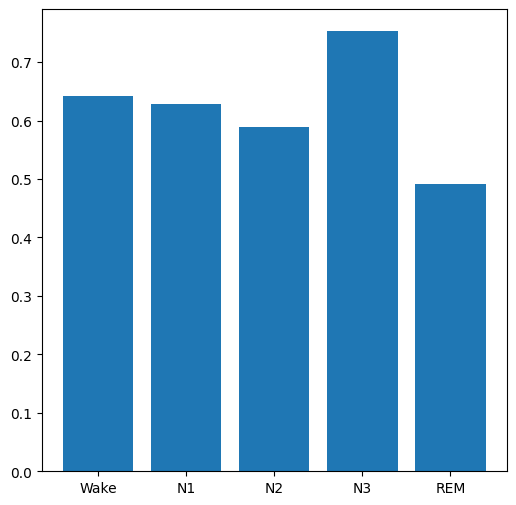

In [33]:
print(test_result["classification_report"])
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.bar(["Wake","N1","N2","N3","REM"],[0.6415,0.6289,0.5892,0.7527,0.4920])
plt.show()

## Calculating MI

### extract feature vectors

In [114]:
@torch.no_grad()
def extract_cnn_features(model, loader, cfg):
    model.eval()

    all_features = []
    all_labels = []
    all_preds = []

    for xb, yb in loader:
        xb = xb.to(cfg.device)

        logits, emb = model(xb, return_embedding=True)

        preds = logits.argmax(dim=1)

        all_features.append(emb.cpu().numpy())
        all_labels.append(yb.numpy())
        all_preds.append(preds.cpu().numpy())

    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    preds = np.concatenate(all_preds, axis=0)

    return features, labels, preds

cnn_features, cnn_labels, cnn_preds = extract_cnn_features(
    model=model,
    loader=loaders["test"],
    cfg=cfg
)

print("CNN features:", cnn_features.shape)
print("CNN labels:", cnn_labels.shape)
print("CNN preds:", cnn_preds.shape)

CNN features: (4632, 256)
CNN labels: (4632,)
CNN preds: (4632,)


### make consecutive pairs

In [115]:
def make_cnn_consecutive_pairs(features, labels, groups_test):
    """
    Creates consecutive feature pairs without crossing patients.

    features:    (N_test, D)
    labels:      (N_test,)
    groups_test: (N_test,)
    """

    X_t = []
    X_t1 = []

    y_t = []
    y_t1 = []

    for i in range(len(labels) - 1):

        # do not cross patient boundary
        if groups_test[i] != groups_test[i + 1]:
            continue

        X_t.append(features[i])
        X_t1.append(features[i + 1])

        y_t.append(labels[i])
        y_t1.append(labels[i + 1])

    return (
        np.asarray(X_t),
        np.asarray(X_t1),
        np.asarray(y_t),
        np.asarray(y_t1),
    )

groups_test = groups[split["test"]]

X_t, X_t1, y_t, y_t1 = make_cnn_consecutive_pairs(
    features=cnn_features,
    labels=cnn_labels,
    groups_test=groups_test
)

print("X_t:", X_t.shape)
print("X_t1:", X_t1.shape)
print("y_t:", y_t.shape)
print("y_t1:", y_t1.shape)

X_t: (4601, 256)
X_t1: (4601, 256)
y_t: (4601,)
y_t1: (4601,)


### calculate MI between feature vectors

In [116]:
from sklearn.feature_selection import mutual_info_regression

def mutual_information_between_feature_vectors(X_t, X_t1, random_state=42):
    """
    Calculates MI between corresponding feature dimensions:
        feature_t[d] and feature_t+1[d]
    """

    mi_scores = []

    for d in range(X_t.shape[1]):
        mi_d = mutual_info_regression(
            X_t[:, [d]],
            X_t1[:, d],
            random_state=random_state
        )[0]

        mi_scores.append(mi_d)

    return np.asarray(mi_scores)

### calculating transition MI

In [118]:
def transition_mutual_information(
    X_t,
    X_t1,
    y_t,
    y_t1,
    n_classes=5,
    min_samples=20,
):
    results = {}

    for current_stage in range(n_classes):
        for next_stage in range(n_classes):

            mask = (y_t == current_stage) & (y_t1 == next_stage)

            count = int(mask.sum())

            if count < min_samples:
                continue

            mi_scores = mutual_information_between_feature_vectors(
                X_t[mask],
                X_t1[mask]
            )

            results[(current_stage, next_stage)] = {
                "count": count,
                "mean_mi": float(mi_scores.mean()),
                "median_mi": float(np.median(mi_scores)),
                "max_mi": float(mi_scores.max()),
                "mi_per_dimension": mi_scores,
            }

    return results

cnn_transition_mi = transition_mutual_information(
    X_t=X_t,
    X_t1=X_t1,
    y_t=y_t,
    y_t1=y_t1,
    n_classes=cfg.n_classes,
    min_samples=20,
)

### transition matrix

In [119]:
def make_mi_transition_matrix(transition_mi, n_classes=5):
    mat = np.full((n_classes, n_classes), np.nan)

    for (a, b), vals in transition_mi.items():
        mat[a, b] = vals["mean_mi"]

    return mat

cnn_mi_matrix = make_mi_transition_matrix(
    cnn_transition_mi,
    n_classes=cfg.n_classes
)

print(cnn_mi_matrix)

[[       nan 0.00683818 0.04608498        nan        nan]
 [0.026991          nan 0.01567563        nan 0.01303866]
 [0.00403674 0.01783756        nan 0.05186471 0.01408497]
 [0.00844523        nan 0.02237674 0.01514946        nan]
 [0.0534386  0.00401362 0.03809776        nan        nan]]


### transition heatmap

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


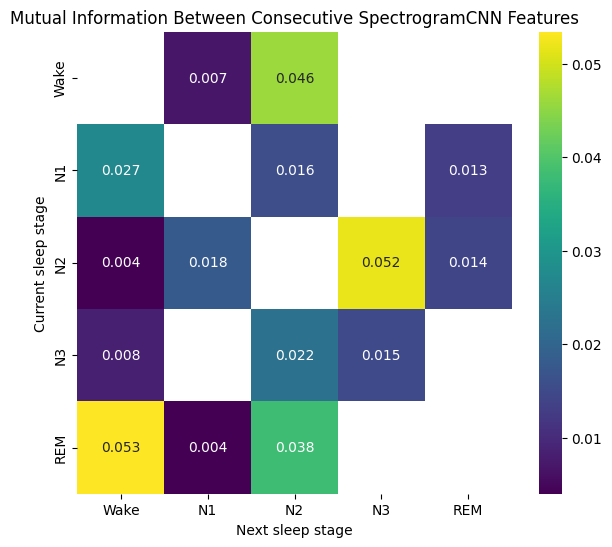

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAMES = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

plt.figure(figsize=(7, 6))
sns.heatmap(
    cnn_mi_matrix,
    annot=True,
    fmt=".3f",
    xticklabels=[LABEL_NAMES[i] for i in range(cfg.n_classes)],
    yticklabels=[LABEL_NAMES[i] for i in range(cfg.n_classes)],
    cmap="viridis"
)

plt.xlabel("Next sleep stage")
plt.ylabel("Current sleep stage")
plt.title("Mutual Information Between Consecutive SpectrogramCNN Features")
plt.show()

# Step 7.3: CNN + BiLSTM (for transition from sleep stages)

In [49]:
@dataclass
class Config:
    processed_dir: str = "/kaggle/input/datasets/aurora1620/sleep-psg-processed-dataset-npz-hypnograms/processed"
    fs: float = 100.0
    n_classes: int = 5
    batch_size: int = 128
    epochs: int = 10
    lr: float = 1e-3
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

In [50]:
def class_weights(y_train, n_classes=5):
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)

    weights = np.log1p(counts.sum() / np.maximum(counts, 1.0))
    weights = weights / weights.mean()

    weights[1] *= 1.5   # N1
    weights[4] *= 1.8   # REM

    return torch.tensor(weights, dtype=torch.float32)

## Create Spectrogram Sequenced Dataset for BiLSTM

In [51]:
# ---------------------------------------------------------------------------
# Pipeline C: Spectrogram -> Residual CNN -> BiLSTM -> Main + Auxiliary Classifier
# ---------------------------------------------------------------------------

import torch

class SpectrogramSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, Z, y, groups, indices, seq_len=7):
        """
        Z:      (N, C, F, TT)
        y:      (N,)
        groups: (N,)
        indices: train/val/test indices from group_split
        """
        self.Z = Z
        self.y = y
        self.groups = groups
        self.indices = np.asarray(indices)
        self.seq_len = seq_len
        self.radius = seq_len // 2

        assert seq_len % 2 == 1, "seq_len should be odd, e.g. 5, 7, 9"

        self.valid_centers = self._make_valid_centers()

    def _make_valid_centers(self):
        valid = []
        index_set = set(self.indices.tolist())

        for center in self.indices:
            pid = self.groups[center]

            start = center - self.radius
            end = center + self.radius

            window = np.arange(start, end + 1)

            if start < 0 or end >= len(self.y):
                continue

            ok = True

            for idx in window:
                if idx not in index_set:
                    ok = False
                    break

                if self.groups[idx] != pid:
                    ok = False
                    break

            if ok:
                valid.append(center)

        return np.asarray(valid, dtype=np.int64)

    def __len__(self):
        return len(self.valid_centers)

    def __getitem__(self, i):
        center = self.valid_centers[i]

        window = np.arange(
            center - self.radius,
            center + self.radius + 1
        )

        x_seq = self.Z[window]          # (S, C, F, TT)
        y_seq = self.y[window]         # (S,)
        y_center = self.y[center]      # scalar

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_seq, dtype=torch.long),
            torch.tensor(y_center, dtype=torch.long),
        )

In [52]:
def make_sequence_loader(Z, y, groups, indices, batch_size, seq_len, shuffle):
    ds = SpectrogramSequenceDataset(
        Z=Z,
        y=y,
        groups=groups,
        indices=indices,
        seq_len=seq_len,
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
    )

## Residual CNN Block 

In [53]:
class ResidualCNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, pool=True, dropout=0.1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((2, 1)) if pool else nn.Identity()
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        """
        x shape:
            (B*S, C, F, TT)
        """

        out = self.conv(x)
        skip = self.skip(x)

        out = self.relu(out + skip)
        out = self.pool(out)
        out = self.dropout(out)

        return out

## CNN + BiLSTM architecture

In [54]:
class CNNBiLSTMAuxSleepNet(nn.Module):
    def __init__(
        self,
        in_channels,
        n_classes=5,
        embedding_dim=256,
        lstm_hidden=128,
        lstm_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        self.cnn = nn.Sequential(
            ResidualCNNBlock(in_channels, 32, pool=True, dropout=0.10),
            ResidualCNNBlock(32, 64, pool=True, dropout=0.15),
            ResidualCNNBlock(64, 128, pool=True, dropout=0.20),
            ResidualCNNBlock(128, 256, pool=False, dropout=0.20),
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, embedding_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.aux_classifier = nn.Linear(embedding_dim, n_classes)

        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.main_classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x, return_features=False):
        """
        x shape:
            (B, S, C, F, TT)
        """
    
        B, S, C, F, TT = x.shape
    
        x = x.view(B * S, C, F, TT)
    
        z = self.cnn(x)
        cnn_emb = self.embedding(z)
    
        aux_logits = self.aux_classifier(cnn_emb)
    
        cnn_seq = cnn_emb.view(B, S, -1)
    
        lstm_out, _ = self.bilstm(cnn_seq)
    
        main_logits = self.main_classifier(lstm_out)
    
        aux_logits = aux_logits.view(B, S, -1)
    
        if return_features:
            return main_logits, aux_logits, cnn_seq, lstm_out
    
        return main_logits, aux_logits

In [55]:
def train_bilstm_model(
    model,
    loaders,
    y_train,
    cfg,
    aux_weight=0.3,
):
    model = model.to(cfg.device)

    loss_fn = nn.CrossEntropyLoss(
        weight=class_weights(y_train, cfg.n_classes).to(cfg.device)
    )

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=1e-3
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="max",
        factor=0.5,
        patience=6
    )

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        train_losses = []

        for xb, y_seq, _ in loaders["train"]:
            xb = xb.to(cfg.device)
            y_seq = y_seq.to(cfg.device)

            opt.zero_grad()

            main_logits, aux_logits = model(xb)

            main_loss = loss_fn(
                main_logits.reshape(-1, cfg.n_classes),
                y_seq.reshape(-1)
            )

            aux_loss = loss_fn(
                aux_logits.reshape(-1, cfg.n_classes),
                y_seq.reshape(-1)
            )

            loss = main_loss + aux_weight * aux_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            train_losses.append(loss.item())

        val_result = evaluate_bilstm_model(
            model,
            loaders["val"],
            cfg,
            quiet=True
        )

        val_f1 = val_result["macro_f1"]

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"epoch={epoch:02d} "
            f"train_loss={np.mean(train_losses):.4f} "
            f"val_macro_f1={val_f1:.4f}"
        )

        scheduler.step(val_f1)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

In [56]:
def evaluate_bilstm_model(model, loader, cfg, quiet=False):
    model.eval()

    preds = []
    true = []

    center_pos = loader.dataset.radius

    with torch.no_grad():
        for xb, _, y_center in loader:
            xb = xb.to(cfg.device)

            main_logits, aux_logits = model(xb)

            center_logits = main_logits[:, center_pos, :]

            batch_preds = center_logits.argmax(dim=1).cpu().numpy()

            preds.extend(batch_preds)
            true.extend(y_center.numpy())

    preds = np.asarray(preds)
    true = np.asarray(true)

    result = {
        "accuracy": accuracy_score(true, preds),
        "macro_f1": f1_score(true, preds, average="macro"),
        "confusion_matrix": confusion_matrix(true, preds),
        "classification_report": classification_report(
            true,
            preds,
            target_names=list(LABEL_NAMES.values()),
            digits=4
        ),
    }

    if not quiet:
        print(f"accuracy={result['accuracy']:.4f} macro_f1={result['macro_f1']:.4f}")
        print(result["classification_report"])
        print(result["confusion_matrix"])

    return result

## CNN RNN Pipeline

In [57]:
def run_cnn_bilstm_aux_pipeline(cfg: Config) -> Dict[str, object]:
    X, y, groups = load_patient_npz(cfg.processed_dir)

    split = group_split(
        X,
        y,
        groups,
        seed=cfg.seed
    )

    Z = make_spectrogram_tensor(X, fs=cfg.fs)
    Z = standardize_spectrograms_by_train(Z, split).astype(np.float32)

    seq_len = 7

    loaders = {
        k: make_sequence_loader(
            Z=Z,
            y=y,
            groups=groups,
            indices=idx,
            batch_size=cfg.batch_size,
            seq_len=seq_len,
            shuffle=(k == "train")
        )
        for k, idx in split.items()
    }

    print("Train sequences:", len(loaders["train"].dataset))
    print("Val sequences:", len(loaders["val"].dataset))
    print("Test sequences:", len(loaders["test"].dataset))

    model = CNNBiLSTMAuxSleepNet(
        in_channels=Z.shape[1],
        n_classes=cfg.n_classes,
        embedding_dim=256,
        lstm_hidden=128,
        lstm_layers=2,
        dropout=0.5,
    )

    model = train_bilstm_model(
        model=model,
        loaders=loaders,
        y_train=y[split["train"]],
        cfg=cfg,
        aux_weight=0.3,
    )

    print("\nCNN + BiLSTM + Auxiliary Classifier pipeline test result")

    return evaluate_bilstm_model(
        model,
        loaders["test"],
        cfg,
        quiet=False
    ), model, loaders

In [61]:
cfg = Config()
cfg

Config(processed_dir='/kaggle/input/datasets/aurora1620/sleep-psg-processed-dataset-npz-hypnograms/processed', fs=100.0, n_classes=5, batch_size=128, epochs=10, lr=0.001, seed=42, device='cuda')

## Training

In [62]:
results, model, loaders = run_cnn_bilstm_aux_pipeline(cfg)

Train sequences: 12883
Val sequences: 3886
Test sequences: 4446
epoch=01 train_loss=1.4646 val_macro_f1=0.6721
epoch=02 train_loss=0.9847 val_macro_f1=0.7539
epoch=03 train_loss=0.8438 val_macro_f1=0.7768
epoch=04 train_loss=0.7514 val_macro_f1=0.7872
epoch=05 train_loss=0.6844 val_macro_f1=0.7840
epoch=06 train_loss=0.6170 val_macro_f1=0.7882
epoch=07 train_loss=0.5484 val_macro_f1=0.7866
epoch=08 train_loss=0.4846 val_macro_f1=0.7970
epoch=09 train_loss=0.4371 val_macro_f1=0.7581
epoch=10 train_loss=0.3894 val_macro_f1=0.7579

CNN + BiLSTM + Auxiliary Classifier pipeline test result
accuracy=0.7971 macro_f1=0.7757
              precision    recall  f1-score   support

        Wake     0.8350    0.8116    0.8231       605
          N1     0.8173    0.8166    0.8170      1145
          N2     0.7973    0.7622    0.7793      1337
          N3     0.7860    0.8806    0.8306      1030
         REM     0.6809    0.5836    0.6285       329

    accuracy                         0.7971      4

## Mutual Information Calculation

In [63]:
results

{'accuracy': 0.7971210076473234,
 'macro_f1': 0.7756998954839134,
 'confusion_matrix': array([[ 491,   83,   23,    5,    3],
        [  68,  935,   67,   31,   44],
        [  21,   66, 1019,  191,   40],
        [   1,   12,  107,  907,    3],
        [   7,   48,   62,   20,  192]]),
 'classification_report': '              precision    recall  f1-score   support\n\n        Wake     0.8350    0.8116    0.8231       605\n          N1     0.8173    0.8166    0.8170      1145\n          N2     0.7973    0.7622    0.7793      1337\n          N3     0.7860    0.8806    0.8306      1030\n         REM     0.6809    0.5836    0.6285       329\n\n    accuracy                         0.7971      4446\n   macro avg     0.7833    0.7709    0.7757      4446\nweighted avg     0.7964    0.7971    0.7957      4446\n'}

### extract sequenced features

In [64]:
@torch.no_grad()
def extract_sequence_features(model, loader, cfg):
    model.eval()

    all_lstm_features = []
    all_cnn_features = []
    all_labels = []
    all_center_labels = []

    for xb, y_seq, y_center in loader:
        xb = xb.to(cfg.device)

        main_logits, aux_logits, cnn_seq, lstm_out = model(
            xb,
            return_features=True
        )

        all_cnn_features.append(cnn_seq.cpu().numpy())
        all_lstm_features.append(lstm_out.cpu().numpy())
        all_labels.append(y_seq.numpy())
        all_center_labels.append(y_center.numpy())

    cnn_features = np.concatenate(all_cnn_features, axis=0)
    lstm_features = np.concatenate(all_lstm_features, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    center_labels = np.concatenate(all_center_labels, axis=0)

    return {
        "cnn_features": cnn_features,
        "lstm_features": lstm_features,
        "labels": labels,
        "center_labels": center_labels,
    }

In [65]:
features_dict = extract_sequence_features(
    model=model,
    loader=loaders["test"],
    cfg=cfg
)

cnn_features = features_dict["cnn_features"]
lstm_features = features_dict["lstm_features"]
labels = features_dict["labels"]

print("CNN features:", cnn_features.shape)
print("BiLSTM features:", lstm_features.shape)
print("Labels:", labels.shape)

CNN features: (4446, 7, 256)
BiLSTM features: (4446, 7, 256)
Labels: (4446, 7)


### make consecutive transition pairs

In [67]:
def make_consecutive_transition_pairs(features, labels):
    """
    features: (N_seq, seq_len, feature_dim)
    labels:   (N_seq, seq_len)

    returns:
        X_t:   features at time t
        X_t1:  features at time t+1
        y_t:   label at time t
        y_t1:  label at time t+1
    """

    X_t, X_t1 = [], []
    y_t, y_t1 = [], []

    for seq_feat, seq_lab in zip(features, labels):
        for i in range(seq_lab.shape[0] - 1):
            X_t.append(seq_feat[i])
            X_t1.append(seq_feat[i + 1])

            y_t.append(seq_lab[i])
            y_t1.append(seq_lab[i + 1])

    return (
        np.asarray(X_t),
        np.asarray(X_t1),
        np.asarray(y_t),
        np.asarray(y_t1),
    )

X_t, X_t1, y_t, y_t1 = make_consecutive_transition_pairs(
    lstm_features,
    labels
)

print("X_t:", X_t.shape)
print("X_t1:", X_t1.shape)
print("y_t:", y_t.shape)
print("y_t1:", y_t1.shape)

X_t: (26676, 256)
X_t1: (26676, 256)
y_t: (26676,)
y_t1: (26676,)


### calculate MI between features vectors

In [68]:
from sklearn.feature_selection import mutual_info_regression

def mutual_information_between_feature_vectors(X_t, X_t1, random_state=42):
    """
    Calculates MI between corresponding dimensions of:
        feature_t[d] and feature_t+1[d]

    X_t:  (N, D)
    X_t1: (N, D)

    returns:
        mi_scores: (D,)
    """

    mi_scores = []

    for d in range(X_t.shape[1]):
        mi_d = mutual_info_regression(
            X_t[:, [d]],
            X_t1[:, d],
            random_state=random_state
        )[0]

        mi_scores.append(mi_d)

    return np.asarray(mi_scores)

### calculate transition MI

In [70]:
def transition_mutual_information(
    X_t,
    X_t1,
    y_t,
    y_t1,
    n_classes=5,
    min_samples=20,
):
    results = {}

    for current_stage in range(n_classes):
        for next_stage in range(n_classes):

            mask = (y_t == current_stage) & (y_t1 == next_stage)

            count = int(mask.sum())

            if count < min_samples:
                continue

            mi_scores = mutual_information_between_feature_vectors(
                X_t[mask],
                X_t1[mask]
            )

            results[(current_stage, next_stage)] = {
                "count": count,
                "mean_mi": float(mi_scores.mean()),
                "median_mi": float(np.median(mi_scores)),
                "max_mi": float(mi_scores.max()),
                "mi_per_dimension": mi_scores,
            }

    return results

transition_mi = transition_mutual_information(
    X_t=X_t,
    X_t1=X_t1,
    y_t=y_t,
    y_t1=y_t1,
    n_classes=cfg.n_classes,
    min_samples=20,
)

In [71]:
for (a, b), vals in transition_mi.items():
    print(
        f"{LABEL_NAMES[a]} → {LABEL_NAMES[b]} | "
        f"n={vals['count']} | "
        f"mean_MI={vals['mean_mi']:.4f} | "
        f"median_MI={vals['median_mi']:.4f} | "
        f"max_MI={vals['max_mi']:.4f}"
    )

Wake → N1 | n=3452 | mean_MI=0.3267 | median_MI=0.2909 | max_MI=1.0813
Wake → N2 | n=151 | mean_MI=0.4960 | median_MI=0.4655 | max_MI=1.2777
Wake → REM | n=76 | mean_MI=0.5975 | median_MI=0.5710 | max_MI=1.4341
N1 → Wake | n=1986 | mean_MI=0.3237 | median_MI=0.2895 | max_MI=1.1523
N1 → N2 | n=4002 | mean_MI=0.2933 | median_MI=0.2609 | max_MI=0.7585
N1 → REM | n=830 | mean_MI=0.4340 | median_MI=0.4110 | max_MI=1.0343
N2 → Wake | n=1080 | mean_MI=0.3078 | median_MI=0.2849 | max_MI=1.1228
N2 → N1 | n=2239 | mean_MI=0.2691 | median_MI=0.2443 | max_MI=0.7664
N2 → N3 | n=3694 | mean_MI=0.3006 | median_MI=0.2393 | max_MI=1.1605
N2 → REM | n=998 | mean_MI=0.4008 | median_MI=0.3821 | max_MI=1.3224
N3 → Wake | n=150 | mean_MI=0.4319 | median_MI=0.3912 | max_MI=1.3465
N3 → N1 | n=90 | mean_MI=0.4100 | median_MI=0.3769 | max_MI=1.3072
N3 → N2 | n=3441 | mean_MI=0.2985 | median_MI=0.2352 | max_MI=1.4520
N3 → N3 | n=2460 | mean_MI=0.3230 | median_MI=0.2731 | max_MI=1.1001
N3 → REM | n=30 | mean_MI=0

### make transition matrix

In [72]:
def make_mi_transition_matrix(transition_mi, n_classes=5):
    mat = np.full((n_classes, n_classes), np.nan)

    for (a, b), vals in transition_mi.items():
        mat[a, b] = vals["mean_mi"]

    return mat

In [73]:
mi_matrix = make_mi_transition_matrix(
    transition_mi,
    n_classes=cfg.n_classes
)

print(mi_matrix)

[[       nan 0.32667502 0.49602909        nan 0.59754573]
 [0.3237239         nan 0.29332616        nan 0.43398307]
 [0.3077524  0.26911969        nan 0.300562   0.40075572]
 [0.43185476 0.40998048 0.29849722 0.32301282 0.37733497]
 [0.38650145 0.33101858 0.55469558        nan 0.58235443]]


### plot MI heatmap

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


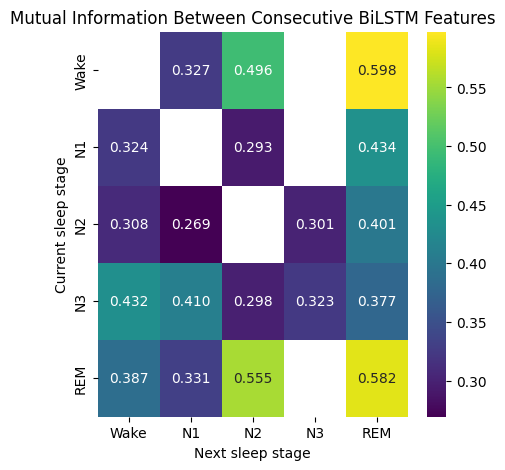

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.heatmap(
    mi_matrix,
    annot=True,
    fmt=".3f",
    xticklabels=[LABEL_NAMES[i] for i in range(cfg.n_classes)],
    yticklabels=[LABEL_NAMES[i] for i in range(cfg.n_classes)],
    cmap="viridis"
)
plt.xlabel("Next sleep stage")
plt.ylabel("Current sleep stage")
plt.title("Mutual Information Between Consecutive BiLSTM Features")
plt.show()